In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'figure.titleweight' : 'bold',
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 10


## Exercise 10.1-2
### Assignment

Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.
Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.

Do you improve with respect using the same number of computing cores but with **independent GA searches** ?

### Solution

### 1. Code Architecture
Here I report a brief explanation of the modification executed on the code of the exercise 9.
- A function to initialize RNG with different numbers for each node.
```c++
    void InitializeRNG(Random& _rnd, int rank) {
        int p1, p2;
        std::ifstream Primes("../INPUT/Primes");
        if (Primes.is_open()) {
            // Skip the first 'rank' lines to get different primes for each process
            for (int i = 0; i <= rank; i++) {
                Primes >> p1 >> p2;            
            }
        }
        // ...
    }
```

- A function to broadcast the map to all nodes.
```c++
    void CityMap::bcast_cities() {    
        MPI_Bcast(_coordinates.memptr(), _N * 2, MPI_DOUBLE, 0, MPI_COMM_WORLD);
    }
```

- I implemented a migration every 50 generation, where the best individual of each continet is sent to the next one. To do this I use `MPI_Isend` to send the data instantly, `MPI_Recv` to receive it, and `MPI_Wait` to be sure that all processes finish. The code is reported here.
```c++
    // Migration: every 50 generations, each process sends its best individual to the next process and receives the best individual from the previous one
    if (i % 50 == 0) {
        MPI_Request req;
        int itag=1;
        
        // Perform an instantaneous send, to node (rank + 1) mod size (cyclic condition)
        MPI_Isend(pop.get_individual(0).get_route_ptr(), params.n_cities, MPI_LONG_LONG_INT, (rank + 1) % size, itag, MPI_COMM_WORLD, &req);

        // I wait for the message from the neighbour (rank - 1 + size) % size
        MPI_Recv(pop.get_individual(params.n_individuals - 1).get_route_ptr(), params.n_cities, MPI_LONG_LONG_INT, (rank - 1 + size) % size, itag, MPI_COMM_WORLD, MPI_STATUS_IGNORE);

        // Wait that every message has been received
        MPI_Wait(&req, MPI_STATUS_IGNORE);

        pop.selection(_rnd);
    }
```
- Also, I used `MPI_Gather` and `MPI_Bcast` to do the last comparison between the path, to check wich one is actually the best. 

- Here I report an outline of the main, commented in the fundamental parts. I use the node 0 to perform the actions that only need 1 output (print on file, comparison, ...), and the other ones to perform all the same task.

```c++
    int main(int argc, char* argv[]) {

        // Start MPI
        MPI_Init(&argc, &argv); 
        int size, rank;
        MPI_Comm_size(MPI_COMM_WORLD, &size); // How many of us are there?
        MPI_Comm_rank(MPI_COMM_WORLD, &rank); // Wich number am I?
        // ...
        // Only node 0 initializes files
        if (rank == 0) {
            // File initialization ...
        }
        // Creating a CityMap object
        CityMap map(params);
        // ... 
        map.bcast_cities();                    // Broadcast the cities to all processes
        map.length_eval();                    // Calculate the distance matrix

        // Creating a Population object: it creates the first generation of individuals
        Population pop(params, map, _rnd);

        for (int i = 0; i < params.n_generations; i++){
            pop.selection(_rnd);

            // Migration: every 50 generations, each process sends its best individual to the next process and receives the best individual from the previous one
            if (i % 50 == 0) {
                // Migration algorithm
            }

            // Crossover and mutations ...

            // Only node 0 prints ...
            
            // Move on generations
            pop.move_on_generations();
        }     

        // ____ COMPARISON ____

        // ...
        // Save the best four candidates
        double candidates[size];    // I create it in all nodes but i use it only in node 0
        for(int i = 0; i < size; i++) candidates[i]=0;
        double lunghezza = pop.get_individual(0).get_length();

        // Rank 0 collects all the candidates
        MPI_Gather (&lunghezza, 1, MPI_DOUBLE, candidates, 1, MPI_DOUBLE, 0, MPI_COMM_WORLD);

        // Variable for the winner that every node has
        int best_rank = 0; 

        if (rank == 0) {
            auto ptr_to_min = std::min_element(candidates, candidates + size); // Generate the pointer to where the min element in candidates is
            best_rank = std::distance(candidates, ptr_to_min); // Calculate wich position of the candidates array it is -> it will be the same of the node 
                                                                // (gather works this way, otherwise I wouldn'b be sure that the node 2 put his best length in candidates[2])
        }

        // Rank 0 says to all nodes who won
        MPI_Bcast(&best_rank, 1, MPI_INT, 0, MPI_COMM_WORLD);

        // --- Final switch ---
        if (rank == 0) {
            // If I am NOT the winner, I request the winning route from the victorious node
            if (best_rank != 0) { // Without this condition there would be a deadlock
                // Receive data and write it DIRECTLY into the internal buffer of my individual 0
                MPI_Recv(pop.get_individual(0).get_route_ptr(), params.n_cities, MPI_LONG_LONG_INT, best_rank, 99, MPI_COMM_WORLD, MPI_STATUS_IGNORE); // Node 0 waits until it has received the best path
                
                // Update the length of individual 0, otherwise it will retain its outdated value!
                pop.get_individual(0).length_eval(map);
            } // ...
            // Now the first individual is the best one globally
            pop.print_best_route(best_route_filepath, params.n_cities);

            // ...

        } else if (rank == best_rank) {
            // If i'm not zero, but the speaker just said my name:
            // I send my individual to rank 0
            MPI_Send(pop.get_individual(0).get_route_ptr(), params.n_cities, MPI_LONG_LONG_INT, 0, 99, MPI_COMM_WORLD);
        }

        // Shut off MPI
        MPI_Finalize();

        return 0;
    }
```

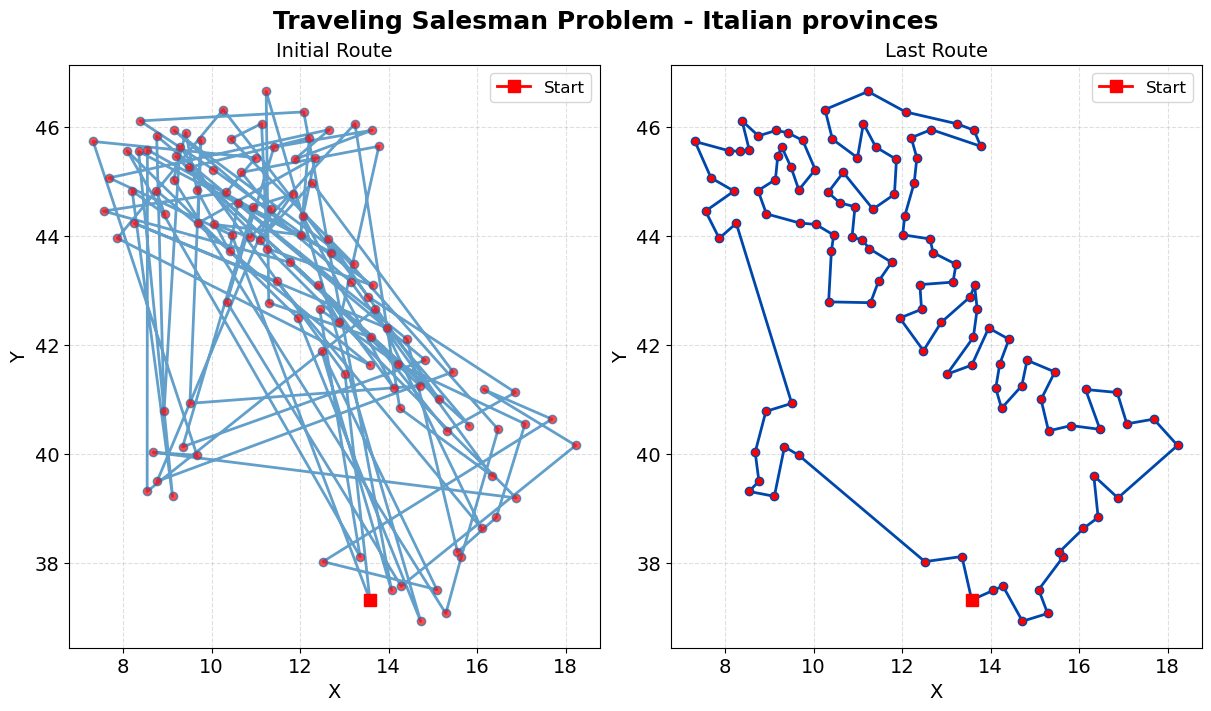

In [5]:
# Configuration Files
file_prov_ita = "OUTPUT_prov_ita_2k3k/best_route_history.dat"

# Helper Function for Data Extraction
def extract_routes(filename):
    """
    Reads the TSP history file and extracts the very first and the optimized last route.
    Returns: x_first, y_first, x_last, y_last, n_cities
    """
    with open(filename, 'r') as file:
        lines = file.readlines()
        n_cities = int(lines[2])

    # Load the entire history of routes
    x, y = np.loadtxt(filename, unpack=True, skiprows=3)

    # Extract and close the FIRST route
    x_first = x[0:n_cities]
    y_first = y[0:n_cities]
    x_first = np.append(x_first, x_first[0])
    y_first = np.append(y_first, y_first[0])

    # Extract and close the LAST route (optimized)
    x_last = x[-n_cities:]
    y_last = y[-n_cities:]
    x_last = np.append(x_last, x_last[0])
    y_last = np.append(y_last, y_last[0])

    return x_first, y_first, x_last, y_last, n_cities

# =============================================================================

# Extract data for the square distribution
x_f, y_f, x_l, y_l, n = extract_routes(file_prov_ita)

# Plotting the Results (2x2 Grid)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 7), constrained_layout=True)

# 1A: Initial Route
ax[0].plot(x_f, y_f, marker='o', markerfacecolor=light_colors[1], linestyle='-', linewidth=2, markersize=6, color='tab:blue', alpha=0.7)
ax[0].plot(x_f[0], y_f[0], marker='s', color='red', markersize=8, label='Start')
ax[0].set_title(f"Initial Route", fontsize=14)
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")
ax[0].legend()

# 1B: Optimized Route
ax[1].plot(x_l, y_l, marker='o', linestyle='-', linewidth=2, markersize=6, markerfacecolor=light_colors[1],)
ax[1].plot(x_l[0], y_l[0], marker='s', color='red', markersize=8, label='Start')
ax[1].set_title(f"Last Route", fontsize=14)
ax[1].set_xlabel("X")
ax[1].set_ylabel("Y")
ax[1].legend()

# General title for the entire figure
fig.suptitle("Traveling Salesman Problem - Italian provinces", fontsize=18)

# plt.savefig("tsp_optimization_comparison.png", dpi=300) 
plt.show()

Here are reported the first and last routes created by the algorithm. The data come from a simulation performed with these parameters:

```text
N_INDIVIDUALS   2000
N_GENERATIONS   3000
MUTATION_RATE   0.4
CROSSOVER_RATE  0.6
SELECTION_EXPONENT   2
N_BEST_TO_SAVE  1
```
Most of the parameters have been inherithed by the consideration made in Exercise 9. The number of individuals and generation has been incremented because the problem is expected to be computationally harder than the one with 34 cities.
I performed all the parallel simulations in this exercise using the 4 phisical cores of my laptop, thus I expect the data not to be very different from a single core computation.

At first glance, the solution proposed seems good, since there are no loops. Once again, to visualize it a GIF of the evolution has been made. 


Trovati 69 percorsi nel file. Generazione GIF in corso...
GIF salvata con successo come 'OUTPUT/tsp_ottimizzazione.gif'!


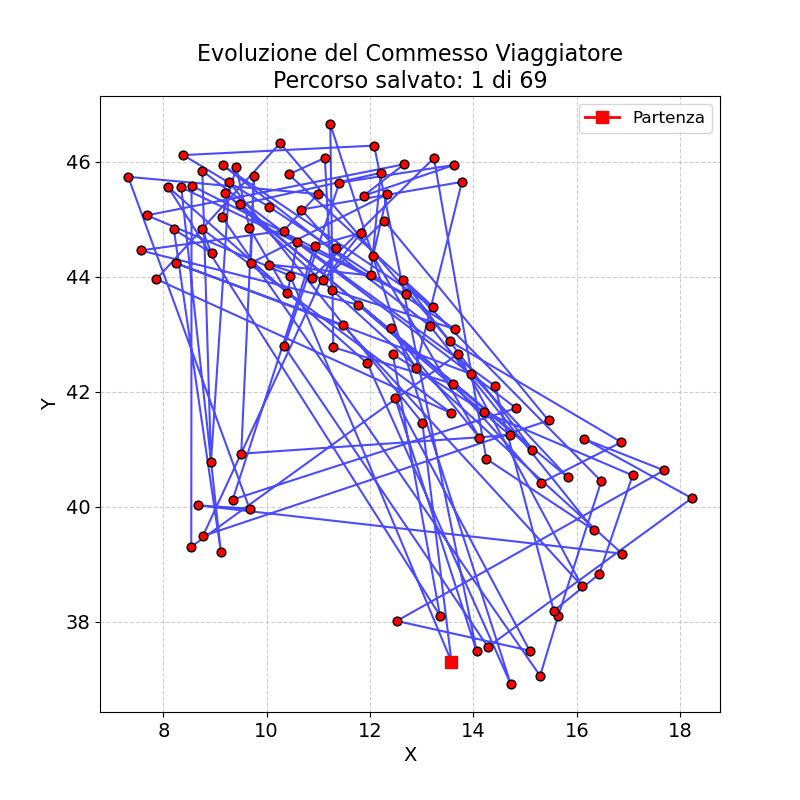

In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

def plot_tsp_evolution(filepath, gif_filename="tsp_evolution.gif", fps=10):
    routes = []
    current_route = []
    n_cities = 0

    # 1. LETTURA E PARSING DEL FILE
    with open(filepath, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        # Salto le righe vuote o i commenti
        if not line or line.startswith('#'):
            continue
        
        parts = line.split()
        
        # Se c'è un solo numero, è il numero di città (N)
        if len(parts) == 1:
            n_cities = int(parts[0])
            continue

        # Se ci sono due numeri, sono le coordinate X e Y
        if len(parts) == 2 and n_cities > 0:
            x, y = float(parts[0]), float(parts[1])
            current_route.append((x, y))

            # Se ho letto tutte le N città, il percorso è completo
            if len(current_route) == n_cities:
                # Aggiungo la prima città alla fine per "chiudere" l'anello nel grafico
                current_route.append(current_route[0]) 
                routes.append(np.array(current_route))
                current_route = [] # Resetto per il prossimo percorso

    if not routes:
        print("Nessun percorso valido trovato nel file.")
        return

    print(f"Trovati {len(routes)} percorsi nel file. Generazione GIF in corso...")

    # 2. SETUP DEL GRAFICO
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title("Evoluzione del Commesso Viaggiatore")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle='--', alpha=0.6)

    # Disegno le città come puntini rossi (prendo le coordinate dal primo percorso)
    cities_x = routes[0][:, 0]
    cities_y = routes[0][:, 1]
    ax.scatter(cities_x, cities_y, c='red', zorder=5, s=40, edgecolors='black')
    
    # Evidenzio la città di partenza (indice 0) con un quadrato blu
    ax.plot(cities_x[0], cities_y[0], marker='s', color='red', markersize=8, label="Partenza", zorder=6)
    ax.legend()

    # Creo un oggetto linea "vuoto" che aggiornerò in ogni frame
    line_obj, = ax.plot([], [], 'b-', lw=1.5, alpha=0.7)

    # 3. FUNZIONI PER L'ANIMAZIONE
    def init():
        line_obj.set_data([], [])
        return line_obj,

    def update(frame):
        x = routes[frame][:, 0]
        y = routes[frame][:, 1]
        line_obj.set_data(x, y)
        ax.set_title(f"Evoluzione del Commesso Viaggiatore\nPercorso salvato: {frame + 1} di {len(routes)}")
        return line_obj,

    # Creo l'animazione
    ani = animation.FuncAnimation(
        fig, update, frames=len(routes), 
        init_func=init, blit=True, interval=100
    )

    # 4. SALVATAGGIO
    # Usa 'pillow' come motore per salvare la GIF 
    ani.save(gif_filename, writer='pillow', fps=fps)
    print(f"GIF salvata con successo come '{gif_filename}'!")

    plt.close() # Chiude la figura per non intasare la memoria

# --- COME USARLA ---
# Sostituisci con il percorso reale del tuo file
file_percorsi = "OUTPUT_prov_ita_2k3k/best_route_history.dat" 
plot_tsp_evolution(file_percorsi, gif_filename="OUTPUT/tsp_ottimizzazione.gif", fps=5)


from IPython.display import Image
Image(filename="OUTPUT/tsp_ottimizzazione.gif")



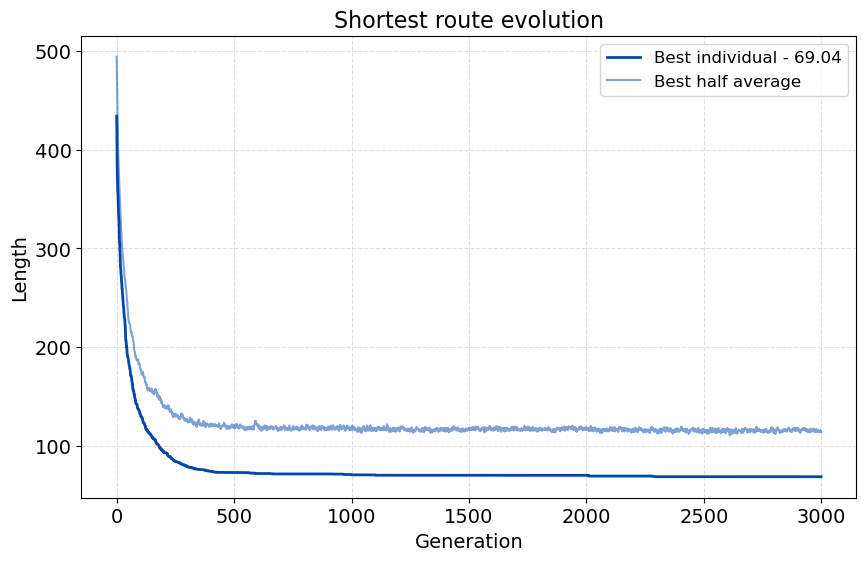

In [7]:
# Configuration File
file_square = ["OUTPUT_prov_ita_2k3k/best_length_history.dat", "OUTPUT_prov_ita_2k3k/half_length_history.dat"]


labels = ['Best individual', 'Best half average']

best_length = np.loadtxt(file_square[0])
half_length = np.loadtxt(file_square[1])

plt.plot(best_length, 
        linestyle='-',     # Unisce le città con una linea continua
        label=[labels[0] + f' - {best_length[-1]:.2f}']
        )

plt.plot(half_length, 
        linestyle='-',     # Unisce le città con una linea continua
        color=light_colors[0], alpha=0.5,
        linewidth=1.5,     # Spessore della linea
        label=labels[1]
        )

plt.title('Shortest route evolution')
plt.xlabel("Generation")
plt.ylabel("Length")
plt.legend(loc='best')

From the GIF and from the length plot, it is possible to observe that the algorithm converges pretty fast to a good solution, and later it performs just small adjustments. The big of the work is done in the first 500 generations out of 3'000. Out of curiosity, I performed a brief exploration of the MUTATION_RATE parameter.

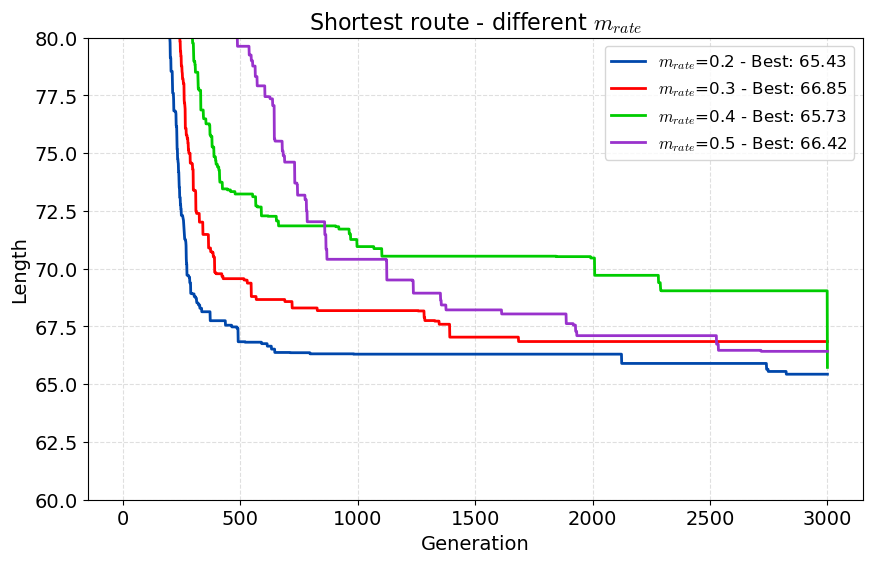

In [8]:
# Configuration File
paths = ["OUTPUT_prov_ita_02/best_length_history.dat", 
        "OUTPUT_prov_ita_03/best_length_history.dat",
        "OUTPUT_prov_ita_04/best_length_history.dat",
        "OUTPUT_prov_ita_05/best_length_history.dat"]

labels = [r'$m_{rate}$=0.2',
          r'$m_{rate}$=0.3',
          r'$m_{rate}$=0.4',
          r'$m_{rate}$=0.5']

for index, file in enumerate(paths) : 
    best_length = np.loadtxt(file)

    plt.plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            label=[labels[index] + f' - Best: {best_length[-1]:.2f}']
            )

# mutations = np.arange(500, 3000, 50)
# for x_val in mutations:
#     plt.axvline(x=x_val, linewidth=0.3, color='black')

plt.title('Shortest route - different $m_{rate}$')
plt.ylim(60, 80)
plt.xlabel("Generation")
plt.ylabel("Length")
plt.legend(loc='best')

Teh $m_{rate}$ parameters that have been explored are [0.2, 0.3, 0.4 (previous simulation), 0.5]. I plotted them zooming only between 60 and 80, to capture the evolution. As expected, the evolution is slow, and characterized by a "step" descent, that corresponds to a mutation or to the passing of a better individual from a node to another. Interestingly, the $m_{rate}$ = 0.4 performs great precisely because of the last comparison made by the code, that executes the final check to see wich node has the shortest route. This can be seen as a big drop in the last position. 

To perform the simulation with or without migrations I added a flag MIGRATIONS to skip or not the migration script. Here are shown the results of the previous simulation, (3k generations, 2k individuals), thath was performed with a migration every 50 generations, and a new simulation, where each node works indipendently and then they compare the best result.


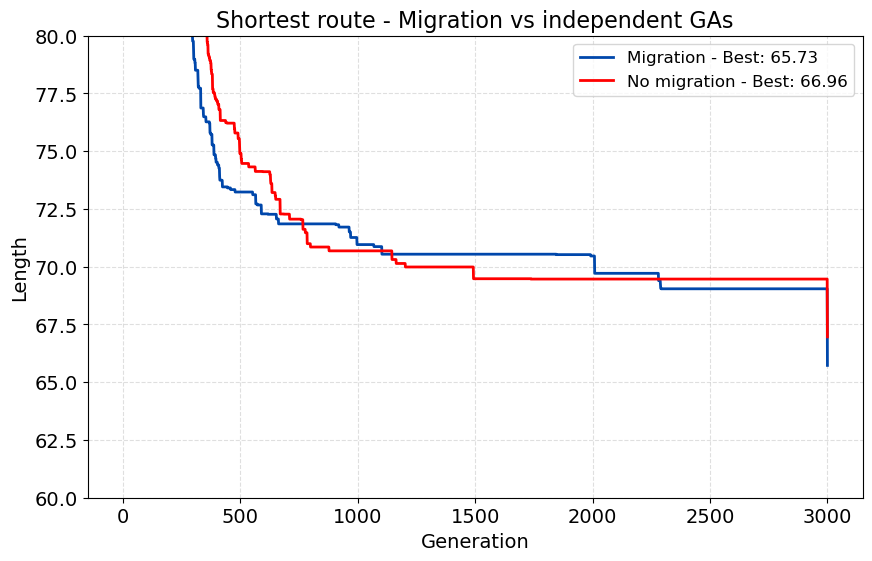

In [9]:
# Configuration File
paths = ["OUTPUT_prov_ita_04/best_length_history.dat", 
        "OUTPUT_prov_ita_04_no_mig/best_length_history.dat"]

labels = [r'Migration',
          r'No migration']

for index, file in enumerate(paths) : 
    best_length = np.loadtxt(file)

    plt.plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            label=[labels[index] + f' - Best: {best_length[-1]:.2f}']
            )

plt.title('Shortest route - Migration vs independent GAs')
plt.ylim(60, 80)
plt.xlabel("Generation")
plt.ylabel("Length")
plt.legend(loc='best')

It is possible to observe how the algorithm without migrations performs quite well overall, but is outperformed by the migrating one, expecially in the last step, where the code compares the different candidates. 

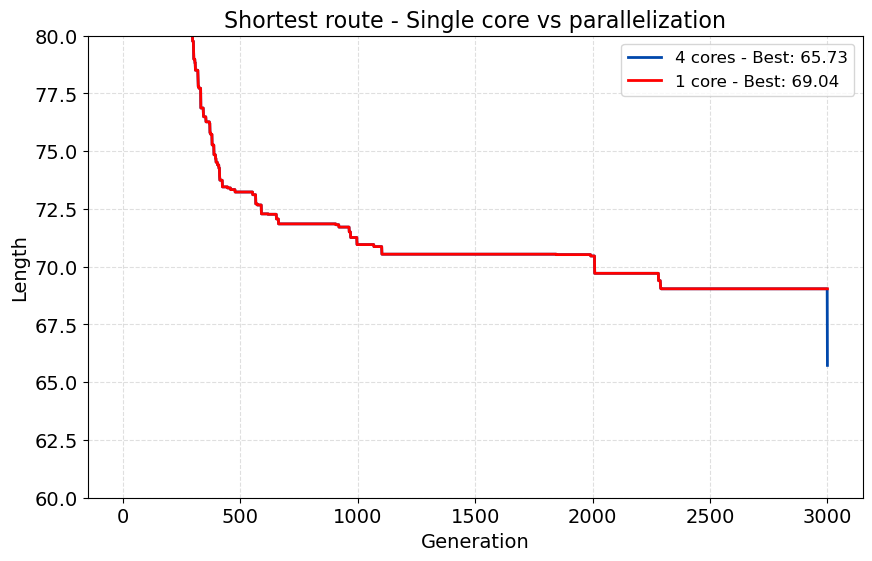

In [10]:
# Configuration File
paths = ["OUTPUT_prov_ita_04/best_length_history.dat", 
         "OUTPUT_prov_ita_1core/best_length_history.dat"]

labels = [r'4 cores',
          r'1 core']

for index, file in enumerate(paths) : 
    best_length = np.loadtxt(file)

    plt.plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            label=[labels[index] + f' - Best: {best_length[-1]:.2f}']
            )

# mutations = np.arange(500, 3000, 50)
# for x_val in mutations:
#     plt.axvline(x=x_val, linewidth=0.3, color='black')

plt.title('Shortest route - Single core vs parallelization')
plt.ylim(60, 80)
plt.xlabel("Generation")
plt.ylabel("Length")
plt.legend(loc='best')

The two curves are perfectly overlapped, and I'm not sure of the reason why the parallelization doesn't improve the simulation on the run, but only with the final comparison, since the migrations sshould help to increase the candidate.

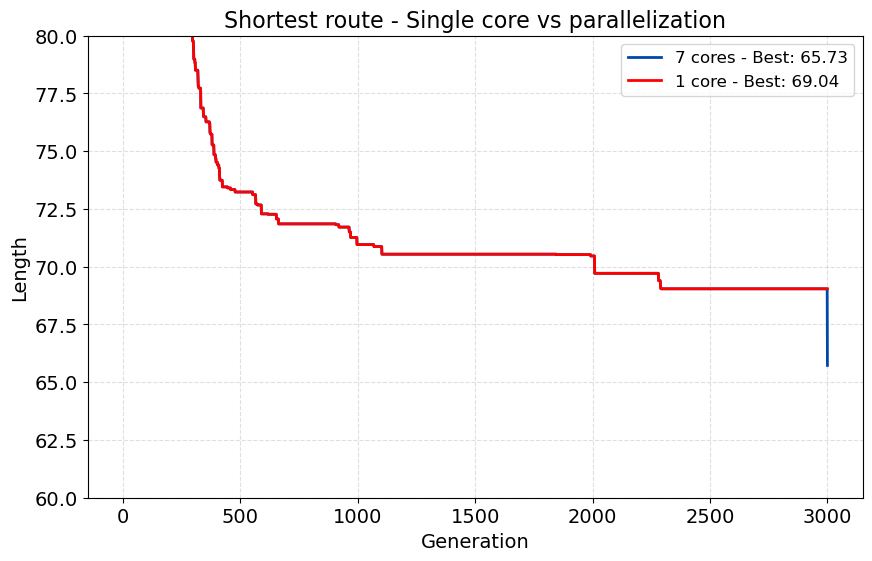

In [11]:
# Configuration File
paths = ["OUTPUT_prov_ita_7core/best_length_history.dat", 
         "OUTPUT_prov_ita_1core/best_length_history.dat"]

labels = [r'7 cores',
          r'1 core']

for index, file in enumerate(paths) : 
    best_length = np.loadtxt(file)

    plt.plot(best_length, 
            linestyle='-',     # Unisce le città con una linea continua
            label=[labels[index] + f' - Best: {best_length[-1]:.2f}']
            )

# mutations = np.arange(500, 3000, 50)
# for x_val in mutations:
#     plt.axvline(x=x_val, linewidth=0.3, color='black')

plt.title('Shortest route - Single core vs parallelization')
plt.ylim(60, 80)
plt.xlabel("Generation")
plt.ylabel("Length")
plt.legend(loc='best')

To investigate furthermore this phenomenon, I tried to run the code on 7 cores (my laptop has 4x2 cores). Despite the great number of cores, the simulation still has the same dyinamic of the single core one, even though it has migrations.